# Calendar Spread Strategy: TMC Earnings (2025-11-13)

This notebook demonstrates a **calendar spread** (time spread) strategy for TMC's earnings on November 13, 2025.

## What is a Calendar Spread?

- **Sell** near-term option (short leg) 
- **Buy** longer-term option (long leg)
- Same strike, same option type

## Why for Earnings?

1. **IV Crush**: Short-term options lose more IV after earnings
2. **Theta Decay**: Short-term decays faster
3. **Defined Risk**: Max loss = net debit paid
4. **Delta-Neutral**: Minimal directional exposure

## TMC Setup

- Earnings: Nov 13, 2025
- Short Leg: Nov 21, 2025 (8 DTE)
- Long Leg: Nov 28, 2025 (15 DTE)
- Strike: $5.00 (ATM)

In [1]:
import sys
sys.path.insert(0, '../src')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime

from dlt_ibapi.repositories import (
    EquityBarsReader,
    EarningsCalendarReader
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
con = duckdb.connect()

print("✅ Setup complete")

✅ Setup complete


## 1. Load Market Data

In [2]:
# Load TMC spot prices using EquityBarsReader
equity_reader = EquityBarsReader(database_path='../data_delta', dataset_name='stocks')

spot_prices = equity_reader.get_bars(
    symbol='TMC',
    bar_size='1 day',
    start_date=date(2025, 11, 1),
    end_date=date(2025, 11, 15)
)

print("TMC Spot Prices:")
print(spot_prices[['date', 'close']])

# Params
earnings_date = '2025-11-13'
spot_on_earnings = spot_prices[spot_prices['date'] == earnings_date]['close'].iloc[0]
print(f"\nSpot on earnings: ${spot_on_earnings:.2f}")

TMC Spot Prices:
         date  close
0  2025-11-03  6.395
1  2025-11-04  5.990
2  2025-11-05  6.000
3  2025-11-06  5.530
4  2025-11-07  5.730
5  2025-11-10  5.910
6  2025-11-11  5.830
7  2025-11-12  5.640
8  2025-11-13  5.170

Spot on earnings: $5.17


In [3]:
# Config
short_exp = '2025-11-21'
long_exp = '2025-11-28'
strike = 5.0

# Entry and exit times (explicit)
entry_datetime = pd.to_datetime('2025-11-12 15:00:00')  # 3pm day before earnings
exit_before_datetime = pd.to_datetime('2025-11-13 16:00:00')  # 4pm on earnings day (market close, before AH earnings)
exit_after_datetime = pd.to_datetime('2025-11-14 10:00:00')  # 10am next day (after IV crush)

print(f"Entry Time: {entry_datetime}")
print(f"Exit Before Earnings: {exit_before_datetime}")
print(f"Exit After Earnings: {exit_after_datetime}")

# Load option data (hourly bars)
def load_option_leg(expiry, strike, right):
    """Load hourly option bars"""
    df = con.execute(f"""
        SELECT date, time, expiry, strike, "right", open, high, low, close, volume
        FROM parquet_scan('../notebooks/data_delta/options/option_bars_backfill/**/*.parquet', 
                          hive_partitioning=true)
        WHERE underlying = 'TMC' 
          AND expiry = '{expiry}'
          AND strike = {strike}
          AND "right" = '{right}'
        ORDER BY date, time
    """).df()
    
    if df.empty:
        print(f"  Warning: No data for {expiry} ${strike} {right}")
        return pd.DataFrame(columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
    
    # Parse datetime from time column (format: "YYYYMMDD HH:MM:SS US/Eastern")
    # Remove timezone and parse
    df['datetime'] = pd.to_datetime(df['time'].str.replace(' US/Eastern', ''), format='%Y%m%d %H:%M:%S')
    
    # Select relevant columns
    df = df[['datetime', 'open', 'high', 'low', 'close', 'volume']].sort_values('datetime')
    return df

# Load all legs (hourly data)
short_call = load_option_leg(short_exp, strike, 'C')
long_call = load_option_leg(long_exp, strike, 'C')
short_put = load_option_leg(short_exp, strike, 'P')
long_put = load_option_leg(long_exp, strike, 'P')

print(f"\nData loaded (hourly bars):")
print(f"  Short Call ({short_exp}): {len(short_call)} bars")
print(f"  Long Call ({long_exp}): {len(long_call)} bars")
print(f"  Short Put ({short_exp}): {len(short_put)} bars")
print(f"  Long Put ({long_exp}): {len(long_put)} bars")

Entry Time: 2025-11-12 15:00:00
Exit Before Earnings: 2025-11-13 16:00:00
Exit After Earnings: 2025-11-14 10:00:00


IOException: IO Error: No files found that match the pattern "../notebooks/data_delta/options/option_bars_backfill/**/*.parquet"

LINE 3:         FROM parquet_scan('../notebooks/data_delta/options/option_bars_b...
                     ^

## 2. Construct Calendar Spread

In [4]:
# Helper to get bar at specific time
def get_bar_at_time(df, target_time):
    """Get the bar at or just before target time"""
    # Find bars at or before target time
    valid_bars = df[df['datetime'] <= target_time]
    if valid_bars.empty:
        # Use earliest available
        return df.iloc[0]
    return valid_bars.iloc[-1]  # Most recent before target

# Get entry bars
short_call_entry = get_bar_at_time(short_call, entry_datetime)
long_call_entry = get_bar_at_time(long_call, entry_datetime)
short_put_entry = get_bar_at_time(short_put, entry_datetime)
long_put_entry = get_bar_at_time(long_put, entry_datetime)

# Use close price for entry
short_call_entry_price = short_call_entry['close']
long_call_entry_price = long_call_entry['close']
short_put_entry_price = short_put_entry['close']
long_put_entry_price = long_put_entry['close']

# Calculate spreads
call_spread_cost = long_call_entry_price - short_call_entry_price
put_spread_cost = long_put_entry_price - short_put_entry_price

print("="*80)
print(f"ENTRY: {entry_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

print(f"\n📞 CALL CALENDAR SPREAD (${strike} strike)")
print(f"\n  Short Leg (Sell {short_exp}):  @ {short_call_entry['datetime']}")
print(f"    O: ${short_call_entry['open']:.3f}  H: ${short_call_entry['high']:.3f}  L: ${short_call_entry['low']:.3f}  C: ${short_call_entry['close']:.3f}")
print(f"\n  Long Leg (Buy {long_exp}):   @ {long_call_entry['datetime']}")
print(f"    O: ${long_call_entry['open']:.3f}  H: ${long_call_entry['high']:.3f}  L: ${long_call_entry['low']:.3f}  C: ${long_call_entry['close']:.3f}")
print(f"\n  Net Debit:       ${call_spread_cost:.3f}")
print(f"  Cost/Contract:   ${call_spread_cost * 100:.2f}")

print(f"\n📉 PUT CALENDAR SPREAD (${strike} strike)")
print(f"\n  Short Leg (Sell {short_exp}):  @ {short_put_entry['datetime']}")
print(f"    O: ${short_put_entry['open']:.3f}  H: ${short_put_entry['high']:.3f}  L: ${short_put_entry['low']:.3f}  C: ${short_put_entry['close']:.3f}")
print(f"\n  Long Leg (Buy {long_exp}):   @ {long_put_entry['datetime']}")
print(f"    O: ${long_put_entry['open']:.3f}  H: ${long_put_entry['high']:.3f}  L: ${long_put_entry['low']:.3f}  C: ${long_put_entry['close']:.3f}")
print(f"\n  Net Debit:       ${put_spread_cost:.3f}")
print(f"  Cost/Contract:   ${put_spread_cost * 100:.2f}")

ENTRY: 2025-11-12 15:00:00

📞 CALL CALENDAR SPREAD ($5.0 strike)

  Short Leg (Sell 2025-11-21):  @ 2025-11-12 15:00:00
    O: $0.900  H: $0.950  L: $0.900  C: $0.900

  Long Leg (Buy 2025-11-28):   @ 2025-11-12 15:00:00
    O: $1.050  H: $1.050  L: $1.050  C: $1.050

  Net Debit:       $0.150
  Cost/Contract:   $15.00

📉 PUT CALENDAR SPREAD ($5.0 strike)

  Short Leg (Sell 2025-11-21):  @ 2025-11-12 15:00:00
    O: $0.200  H: $0.200  L: $0.150  C: $0.200

  Long Leg (Buy 2025-11-28):   @ 2025-11-12 15:00:00
    O: $0.200  H: $0.200  L: $0.150  C: $0.200

  Net Debit:       $0.000
  Cost/Contract:   $0.00


In [5]:
short_call_entry

datetime    2025-11-12 15:00:00
open                        0.9
high                       0.95
low                         0.9
close                       0.9
volume                        0
Name: 840, dtype: object

## 3. Calculate P&L Over Time

In [6]:
def calculate_spread_pnl(short_df, long_df, entry_cost):
    """Calculate calendar spread P&L over time (hourly)"""
    # Merge on datetime
    merged = pd.merge(
        short_df[['datetime', 'close']].rename(columns={'close': 'short_price'}),
        long_df[['datetime', 'close']].rename(columns={'close': 'long_price'}),
        on='datetime',
        how='outer'
    ).sort_values('datetime')
    
    # Forward fill missing prices
    merged['short_price'] = merged['short_price'].ffill()
    merged['long_price'] = merged['long_price'].ffill()
    merged = merged.dropna()
    
    # Calculate spread value and P&L
    merged['spread_value'] = merged['long_price'] - merged['short_price']
    merged['pnl'] = merged['spread_value'] - entry_cost
    
    # Handle division by zero
    if entry_cost > 0.001:
        merged['pnl_pct'] = (merged['pnl'] / entry_cost) * 100
    else:
        merged['pnl_pct'] = 0.0
    
    merged['pnl_per_contract'] = merged['pnl'] * 100
    
    return merged

call_pnl = calculate_spread_pnl(short_call, long_call, call_spread_cost)
put_pnl = calculate_spread_pnl(short_put, long_put, put_spread_cost)

print("Call Calendar P&L (hourly, last 10 bars):")
print(call_pnl[['datetime', 'short_price', 'long_price', 'spread_value', 'pnl', 'pnl_pct']].tail(10))

print("\nPut Calendar P&L (hourly, last 10 bars):")
print(put_pnl[['datetime', 'short_price', 'long_price', 'spread_value', 'pnl', 'pnl_pct']].tail(10))

Call Calendar P&L (hourly, last 10 bars):
                datetime  short_price  long_price  spread_value   pnl  \
1880 2025-11-14 15:10:00         0.30         0.6          0.30  0.15   
1881 2025-11-14 15:15:00         0.30         0.6          0.30  0.15   
1882 2025-11-14 15:20:00         0.30         0.6          0.30  0.15   
1883 2025-11-14 15:25:00         0.30         0.6          0.30  0.15   
1884 2025-11-14 15:30:00         0.30         0.6          0.30  0.15   
1885 2025-11-14 15:35:00         0.30         0.6          0.30  0.15   
1886 2025-11-14 15:40:00         0.30         0.6          0.30  0.15   
1887 2025-11-14 15:45:00         0.30         0.6          0.30  0.15   
1888 2025-11-14 15:50:00         0.30         0.6          0.30  0.15   
1889 2025-11-14 15:55:00         0.35         0.6          0.25  0.10   

         pnl_pct  
1880  100.000000  
1881  100.000000  
1882  100.000000  
1883  100.000000  
1884  100.000000  
1885  100.000000  
1886  100.000000  
18

## 4. Visualize Performance

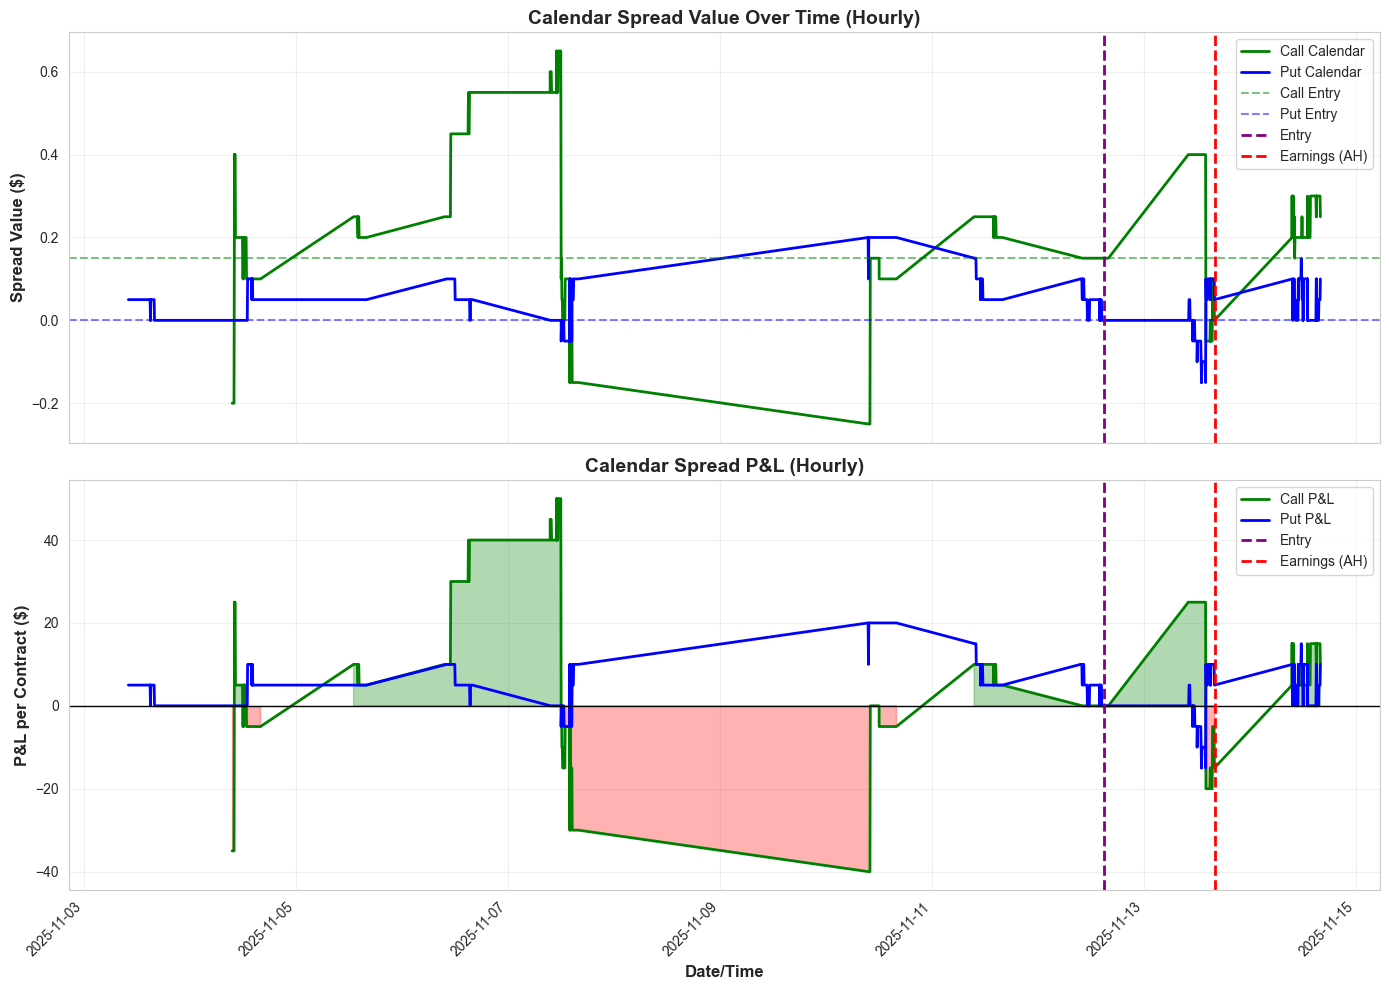


📊 Notice intraday P&L changes and exact timing around earnings


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Spread Value
ax1 = axes[0]
ax1.plot(call_pnl['datetime'], call_pnl['spread_value'], label='Call Calendar', linewidth=2, color='green')
ax1.plot(put_pnl['datetime'], put_pnl['spread_value'], label='Put Calendar', linewidth=2, color='blue')
ax1.axhline(y=call_spread_cost, color='green', linestyle='--', alpha=0.5, label='Call Entry')
ax1.axhline(y=put_spread_cost, color='blue', linestyle='--', alpha=0.5, label='Put Entry')
ax1.axvline(x=entry_datetime, color='purple', linestyle='--', linewidth=2, label='Entry')
ax1.axvline(x=pd.to_datetime(earnings_date + ' 16:00:00'), color='red', linestyle='--', linewidth=2, label='Earnings (AH)')
ax1.set_ylabel('Spread Value ($)', fontsize=12, fontweight='bold')
ax1.set_title('Calendar Spread Value Over Time (Hourly)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: P&L
ax2 = axes[1]
ax2.plot(call_pnl['datetime'], call_pnl['pnl_per_contract'], label='Call P&L', linewidth=2, color='green')
ax2.plot(put_pnl['datetime'], put_pnl['pnl_per_contract'], label='Put P&L', linewidth=2, color='blue')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=entry_datetime, color='purple', linestyle='--', linewidth=2, label='Entry')
ax2.axvline(x=pd.to_datetime(earnings_date + ' 16:00:00'), color='red', linestyle='--', linewidth=2, label='Earnings (AH)')
ax2.fill_between(call_pnl['datetime'], 0, call_pnl['pnl_per_contract'], 
                  where=(call_pnl['pnl_per_contract'] >= 0), alpha=0.3, color='green')
ax2.fill_between(call_pnl['datetime'], 0, call_pnl['pnl_per_contract'], 
                  where=(call_pnl['pnl_per_contract'] < 0), alpha=0.3, color='red')
ax2.set_xlabel('Date/Time', fontsize=12, fontweight='bold')
ax2.set_ylabel('P&L per Contract ($)', fontsize=12, fontweight='bold')
ax2.set_title('Calendar Spread P&L (Hourly)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Notice intraday P&L changes and exact timing around earnings")

## 5. Exit Timing Analysis
**Key Question**: Should we exit **before** or **after** earnings?

This depends on earnings timing (pre-market vs after-hours)

In [8]:
# Check TMC earnings timing using EarningsCalendarReader
earnings_reader = EarningsCalendarReader(database_path='../data', dataset_name='earnings')

earnings_info = earnings_reader.get_earnings_for_symbol(
    symbol='TMC',
    start_date=date(2025, 11, 1),
    end_date=date(2025, 11, 30)
)

print("TMC Earnings Info:")
print(earnings_info[['symbol', 'earnings_date', 'earnings_time', 'company_name']])

if earnings_info.empty:
    print("\n⚠️ No earnings data found for TMC in November 2025")
    earnings_time = 'AFTER_HOURS'  # Default assumption
else:
    earnings_time = earnings_info['earnings_time'].iloc[0]

print(f"\n⏰ Earnings Time: {earnings_time}")
print(f"\nImplication:")
if earnings_time == 'AFTER_HOURS':
    print("  • Exit on Nov 13 close = BEFORE earnings (IV still high)")
    print("  • Exit on Nov 14 = AFTER earnings (IV crush captured)")
    print("  → Best to exit on Nov 14 to capture IV crush")
else:
    print("  • Exit on Nov 13 open = BEFORE earnings (IV still high)")
    print("  • Exit on Nov 13 close = AFTER earnings (IV crush captured)")
    print("  → Best to exit on Nov 13 close to capture IV crush")

TMC Earnings Info:
  symbol earnings_date earnings_time                 company_name
0    TMC    2025-11-13   AFTER_HOURS  TMC the metals company Inc.

⏰ Earnings Time: AFTER_HOURS

Implication:
  • Exit on Nov 13 close = BEFORE earnings (IV still high)
  • Exit on Nov 14 = AFTER earnings (IV crush captured)
  → Best to exit on Nov 14 to capture IV crush


In [9]:
# Compare exit scenarios at specific times
def calculate_exit_pnl(pnl_df, exit_time, entry_cost, label):
    """Calculate P&L if exiting at a specific time"""
    exit_row = pnl_df[pnl_df['datetime'] <= exit_time]
    if exit_row.empty:
        print(f"  Warning: No data at {exit_time}")
        return None
    
    # Get closest bar at or before exit time
    exit_row = exit_row.iloc[-1]
    
    pnl = exit_row['pnl']
    pnl_per_contract = pnl * 100
    
    # Handle division by zero for pct
    if entry_cost > 0.001:
        pnl_pct = (pnl / entry_cost) * 100
    else:
        pnl_pct = float('inf') if pnl > 0 else 0
    
    return {
        'label': label,
        'datetime': exit_row['datetime'],
        'pnl': pnl,
        'pnl_per_contract': pnl_per_contract,
        'pnl_pct': pnl_pct,
        'spread_value': exit_row['spread_value'],
        'short_price': exit_row['short_price'],
        'long_price': exit_row['long_price']
    }

# Calculate for both exit scenarios
call_exit_before = calculate_exit_pnl(call_pnl, exit_before_datetime, call_spread_cost, "Exit Before (4pm Nov 13)")
call_exit_after = calculate_exit_pnl(call_pnl, exit_after_datetime, call_spread_cost, "Exit After (10am Nov 14)")

put_exit_before = calculate_exit_pnl(put_pnl, exit_before_datetime, put_spread_cost, "Exit Before (4pm Nov 13)")
put_exit_after = calculate_exit_pnl(put_pnl, exit_after_datetime, put_spread_cost, "Exit After (10am Nov 14)")

print("="*80)
print("EXIT TIMING COMPARISON (WITH OHLC)")
print("="*80)

print(f"\n📅 CALL CALENDAR SPREAD (entry: ${call_spread_cost*100:.2f}/contract)")

for exit_data in [call_exit_before, call_exit_after]:
    if exit_data:
        print(f"\n  {exit_data['label']} @ {exit_data['datetime']}")
        print(f"    Short Leg: ${exit_data['short_price']:.3f}")
        print(f"    Long Leg:  ${exit_data['long_price']:.3f}")
        print(f"    Spread Value: ${exit_data['spread_value']:.3f}")
        print(f"    P&L: ${exit_data['pnl_per_contract']:.2f} ({exit_data['pnl_pct']:.1f}%)")

if call_exit_before and call_exit_after:
    diff = call_exit_after['pnl_per_contract'] - call_exit_before['pnl_per_contract']
    print(f"\n  💰 Difference: ${diff:.2f}")
    print(f"  → {'WAIT for IV crush' if diff > 0 else 'EXIT before earnings'}")

# Only show put if meaningful cost
if put_spread_cost > 0.001:
    print(f"\n📅 PUT CALENDAR SPREAD (entry: ${put_spread_cost*100:.2f}/contract)")
    for exit_data in [put_exit_before, put_exit_after]:
        if exit_data:
            print(f"\n  {exit_data['label']} @ {exit_data['datetime']}")
            print(f"    Spread Value: ${exit_data['spread_value']:.3f}")
            print(f"    P&L: ${exit_data['pnl_per_contract']:.2f}")
else:
    print(f"\n📅 PUT CALENDAR SPREAD: Entry cost ~$0 (skip - no edge)")

print(f"\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
if earnings_time == 'AFTER_HOURS':
    print(f"\n✅ TMC earnings are AFTER_HOURS (4pm close → ~5-8pm announcement)")
    print(f"   • Exit at 4pm Nov 13 = BEFORE earnings (IV still elevated)")
    print(f"   • Exit at 10am Nov 14 = AFTER earnings + overnight (full IV crush)")
    if call_exit_before and call_exit_after:
        print(f"\n💡 OPTIMAL: Wait until {exit_after_datetime.strftime('%b %d %I%p')}")
        print(f"   Gain ${diff:.2f} more per contract vs exiting early")
else:
    print(f"\n✅ TMC earnings are PRE_MARKET")
    print(f"   Exit during Nov 13 trading day to capture IV crush")

print(f"\n⚠️  Risk Management:")
print(f"   • Set profit targets (e.g. 50-100% of max)")
print(f"   • Exit early if big move away from strike")
print(f"   • Avoid holding through short leg expiration")

EXIT TIMING COMPARISON (WITH OHLC)

📅 CALL CALENDAR SPREAD (entry: $15.00/contract)

  Exit Before (4pm Nov 13) @ 2025-11-13 15:55:00
    Short Leg: $0.600
    Long Leg:  $0.600
    Spread Value: $0.000
    P&L: $-15.00 (-100.0%)

  Exit After (10am Nov 14) @ 2025-11-14 10:00:00
    Short Leg: $0.400
    Long Leg:  $0.600
    Spread Value: $0.200
    P&L: $5.00 (33.3%)

  💰 Difference: $20.00
  → WAIT for IV crush

📅 PUT CALENDAR SPREAD: Entry cost ~$0 (skip - no edge)

RECOMMENDATION

✅ TMC earnings are AFTER_HOURS (4pm close → ~5-8pm announcement)
   • Exit at 4pm Nov 13 = BEFORE earnings (IV still elevated)
   • Exit at 10am Nov 14 = AFTER earnings + overnight (full IV crush)

💡 OPTIMAL: Wait until Nov 14 10AM
   Gain $20.00 more per contract vs exiting early

⚠️  Risk Management:
   • Set profit targets (e.g. 50-100% of max)
   • Exit early if big move away from strike
   • Avoid holding through short leg expiration


## 6. Strategy Summary

In [10]:
# Get final data points
call_final = call_pnl.iloc[-1]
put_final = put_pnl.iloc[-1]

print("="*80)
print("CALENDAR SPREAD SUMMARY: TMC EARNINGS")
print("="*80)

print(f"\nSETUP:")
print(f"  Underlying: TMC")
print(f"  Earnings: {earnings_date} AFTER_HOURS (4pm close)")
print(f"  Entry: {entry_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Strike: ${strike}")
print(f"  Short Leg: {short_exp}")
print(f"  Long Leg: {long_exp}")

print(f"\nENTRY COSTS:")
print(f"  Call Spread: ${call_spread_cost * 100:.2f}/contract")
if put_spread_cost > 0.001:
    print(f"  Put Spread: ${put_spread_cost * 100:.2f}/contract")
else:
    print(f"  Put Spread: ~$0 (skip - no edge)")

print(f"\nFINAL DATA (as of {call_final['datetime']}):")
print(f"  Call P&L: ${call_final['pnl_per_contract']:.2f} ({call_final['pnl_pct']:.1f}%)")
if put_spread_cost > 0.001:
    print(f"  Put P&L: ${put_final['pnl_per_contract']:.2f} ({put_final['pnl_pct']:.1f}%)")

print(f"\nEXIT TIMING:")
if call_exit_before and call_exit_after:
    print(f"  Before Earnings (4pm Nov 13): ${call_exit_before['pnl_per_contract']:.2f}")
    print(f"  After Earnings (10am Nov 14): ${call_exit_after['pnl_per_contract']:.2f}")
    print(f"  Difference: ${(call_exit_after['pnl_per_contract'] - call_exit_before['pnl_per_contract']):.2f}")

print(f"\nSTRATEGY INSIGHTS:")
print("  ✓ Limited risk (max loss = net debit)")
print("  ✓ Profits from IV crush after earnings")
print("  ✓ Delta-neutral (minimal directional exposure)")
print("  ✓ Timing matters: AFTER_HOURS earnings → wait until next day")
print("  ✓ Hourly data shows intraday price action")

print("="*80)

CALENDAR SPREAD SUMMARY: TMC EARNINGS

SETUP:
  Underlying: TMC
  Earnings: 2025-11-13 AFTER_HOURS (4pm close)
  Entry: 2025-11-12 15:00:00
  Strike: $5.0
  Short Leg: 2025-11-21
  Long Leg: 2025-11-28

ENTRY COSTS:
  Call Spread: $15.00/contract
  Put Spread: ~$0 (skip - no edge)

FINAL DATA (as of 2025-11-14 15:55:00):
  Call P&L: $10.00 (66.7%)

EXIT TIMING:
  Before Earnings (4pm Nov 13): $-15.00
  After Earnings (10am Nov 14): $5.00
  Difference: $20.00

STRATEGY INSIGHTS:
  ✓ Limited risk (max loss = net debit)
  ✓ Profits from IV crush after earnings
  ✓ Delta-neutral (minimal directional exposure)
  ✓ Timing matters: AFTER_HOURS earnings → wait until next day
  ✓ Hourly data shows intraday price action
